# Starbucks Customers Segmentation

**Table of Contents:**



1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling & Evaluation
5. Discussion & Conclusion

<!-- 1. [Business Understanding](#business_understanding)
2. [Data Understanding](#data_understanding)  
3. [Data Preparation](#data_preparation)
4. [Modeling & Evaluation](#modeling_evaluation)
5. [Discussion & Conclusion](#discussion_conclusion) -->

# Business Understanding 
Starbucks Corporation is an American coffee company. Today, it operates more than 30,000 retail stores in 80 markets around the world.[[1]](https://www.starbucks.com/about-us/company-information/starbucks-company-profile) The company hence is a big player in a vigorously competitive industry. One approach to retain customers is its [Starbucks Reward Program](https://www.starbucks.com/rewards/). Members of the program receive promotional offers. The company then hopes to use the data collected on its customer behavior to create business value and make data-driven decisions on how it engages with its customers base.

### 1.1. Project Overview

Work in this notebook is related to [Udacity's Data Scientist](https://www.udacity.com/course/data-scientist-nanodegree--nd025?utm_source=gsem_brand&utm_medium=ads_n&utm_campaign=8305564283_c&utm_term=85684766815_sa&utm_keyword=udacity%20data%20science_e&gclid=CjwKCAiA3abwBRBqEiwAKwICA4Cgp53FH7YGsEl-Jd_7to46zhiH3nTGxkv4fpPBaND6bK1tASWO-BoCUeoQAvD_BwE) capstone project. The motivation behind this project is to propose a solution that helps the company in forming a better understanding of its customers base. In this project, an unsupervised learning technique will be used to segment customers and measure how each segment behave during different periods of the test. In particular, [K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) clustering will be used. The provided dataset of courses will go through different phases at first before being ready for modeling. Starting with cleaning and ending with the final dataset grouped by customer profiles with their data aggreated.

Here's a high-level overview of the workflow followed in this project:
1. Define the problem in-hands and measurement criterias.
* Explore, understand, and clean the provided datasets.
* Prepare final dataset grouped by customers.
* Transform final dataset appropriately before fitting model.
* Fit model on final dataset and predict cluster labels.
* Explore distributions among formed clusters.
* Discuss outcomes and make recommendations.

### 1.2. Problem Statement

The company currently promotes products to customers with no prior knowledge of their segments. It is possible hence to analyse the data to find patterns in customer behaviors. This helps the company in aiming and tailoring its marketing efforts and resources to consumers who exhibit similar characteristics and are considered most likely to opt in for business's offerings. This form of target marketing is important because it helps the company by maximizing revenue while maintaining promotional campaigns cost smartly low. To do this, an unsupervised learning technique will be used to cluster customers into groups that can be be investigated separately to better understand their qualities and engage them accordingly.

### 1.3. Measurement Criterias

When speaking about measurement criterias, two categories come to mind; _business metrics_ which assist in making decisions from a business point of view, and _technical metrics_ which assist in making assessment of the implementation of the algorithm used to cluster data.

#### 1.3.1. Business Metrics

All features will be investigated as much as possible, but there are two main themes used drive decisions made in this regard:

`1` Distinguish the difference between how customers behave during non-promotional periods and how they behave when they are prompted to do so during promotionals periods. To measure this, [**R**ecency-**F**requency-**M**onetary Analysis](https://en.wikipedia.org/wiki/RFM_(market_research)) for examining customer value is used. In this model, recency, frequency and monetary values are assigned a score from one to five based on quantiles partition dividing range of values into equal-sized intervals. The RFM score is then obtained by taking the average of all three scores.

$$\textrm{RFM}_{score}={\textrm{recency}_{score}+\textrm{frequency}_{score}+\textrm{monetary}_{score}\over3}$$

`2` Identify which customers react preferably to which types of offers. To measure this, offer view and completion rates will be used where the cardinalities of corresponding sets are divided by cardinalities of relevant sets.

$$\textrm{view rate}={n(\textrm{offer viewed})\over{n(\textrm{offer received})}}\;\;\;\;\;\;\;\;\textrm{completion rate}={n(\textrm{offer completed})\over{n(\textrm{offer viewed})}}$$

#### 1.3.1. Technical Metrics

For the algorithm chosen in this problem, K-Means, two appropriate methods will be used find the optimal number of clusters $k$ and to assess the model implementations; silhouette coefficient (SC) analysis and within-cluster Sum of Squared Errors (SSE) analysis.

`1` Silhouette Coefficient (SC) analysis is a way to measure how close each point in a cluster is to the points in its neighboring clusters. Its a neat way to find out the optimum value for k during k-means clustering. Silhouette values lies in the range of [-1, 1]. A value of +1 indicates that the sample is far away from its neighboring cluster and very close to the cluster its assigned. Similarly, value of -1 indicates that the point is close to its neighboring cluster than to the cluster its assigned. And, a value of 0 means at the boundary of the distance between the two cluster. Value of +1 is ideal and -1 is least preferred. Hence, higher the value better is the cluster configuration. [[2]](https://kapilddatascience.wordpress.com/2015/11/10/using-silhouette-analysis-for-selecting-the-number-of-cluster-for-k-means-clustering/)

Mathematically, for one data point $i$ where $a(i)$ represents the calculated mean distance of point $i$ with regard to to all other points in the cluster it was assigned and $b(i)$ represents the calculated mean distance of point $i$ with regard to to all points in its closest neighboring cluster, silhouette is defined:

$$s(i)={b(i)-a(i)\over\textrm{max}\{b(i),a(i))\}}$$

Therefore, it is clear from the above equation that $$-1\leq{s(i)}\leq1$$

Then, for one value representing the silhouette score that used for assessment of clustering outcomes, where $\bar{s}(k)$ represents the mean $s(i)$ over all data of the entire dataset for a specific number of clusters $k$, silhouette coefficient is defined:

$$SC=\textrm{max}_k\{\bar{s}(k)\}$$

`2` Sum of Squared Errors (SSE) analysis is a way to measure variability (dispersion) within a cluster by taking the sum of the squared differences between each data point and its cluster's mean, and therefore defined where $x_i$ is the $i$th data point and $n$ is the total number of data points: [[3]](https://hlab.stanford.edu/brian/error_sum_of_squares.html)

$$SSE=\sum_{i=1}^{n}x_i^2-{1\over{n}}\Bigg(\sum_{i=1}^{n}x_i^2\Bigg)^2$$

SSE tends to decrease toward 0 as $k$-value increase because then each data point is its own cluster and there is no error between it and the mean of its cluster. The elbow method is then applied by plotting SSE for a range of $k$-values where where one should choose a $k$-value after which variability starts to have diminishing returns. [[4]](https://bl.ocks.org/rpgove/0060ff3b656618e9136b)

# 2 Data Understanding

This data set contains simulated data that mimics customer behavior on the Starbucks Rewards mobile app. Once every few days, Starbucks sends out an offer to users of the mobile app. An offer can be merely an advertisement for a drink (informational) or an actual offer such as a discount or BOGO (buy one get one free). This data set is a simplified version of the real Starbucks app because the underlying simulator only has one product whereas Starbucks actually sells dozens of products.

The data is contained in three files mentioned below in brief and will be discussed in details later.

* `data/portfolio.json` - containing meta data about the promotions offered by the company.
* `data/profile.json` - demographic data about members enrolled in the reward program.
* `data/transcript.json` - records for transactions, offers received, offers viewed, and offers completed

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import utilities as u

from IPython.display import display
import pandas as pd
import numpy as np
import json
import time

from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('ggplot')
%matplotlib inline

import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

Read the Json files 

In [14]:
# Read in the json files
from pathlib import Path
data_dir = Path.cwd() / 'Dataset'
portfolio = pd.read_json(data_dir / 'portfolio.json', orient='records', lines=True)
profile = pd.read_json(data_dir / 'profile.json', orient='records', lines=True)
transcript = pd.read_json(data_dir / 'transcript.json', orient='records', lines=True)

### 2.1. `portfolio` Dataset

**Schema:**  
0. `id` (str) - offer id
* `offer_type` (str) - type of offer; bogo, discount, or informational
* `difficulty` (int) - minimum required to be spent to complete an offer
* `reward` (int) - reward given for completing an offer
* `duration` (int) - time in days for an offer to be open
* `channels` (list) - communication channels used to market an offer.

In [15]:
portfolio.head()

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [16]:
portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reward      10 non-null     int64 
 1   channels    10 non-null     object
 2   difficulty  10 non-null     int64 
 3   duration    10 non-null     int64 
 4   offer_type  10 non-null     object
 5   id          10 non-null     object
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes


In [17]:
# Check null values
u.compute_null_pct(portfolio)

    column  count  pct
    reward      0  0.0
  channels      0  0.0
difficulty      0  0.0
  duration      0  0.0
offer_type      0  0.0
        id      0  0.0


**Conclusion:**

This dataset contains meta data about promotions offered by the company. Every offer has a minimum required to be spent by a customer to complete an offer represented by `difficulty` and therfore be eligible for the `reward`. Also, every offer has a validity period represented by `duration` after which it expires.

The above is true for offers with offer type "bogo" and "discount". However, for "informational" offers while they have a `duration`, their `difficulty` and `reward` are zero since these offers are merely providing information about a product. This means they are not tracked for completion in `transcript`.

There are 10 rows (representing 10 types of offers) and 6 columns with no missing or null values. Very little cleaning will be performed on this dataset.

### 2.2. `profile` Dataset

**Schema:**
0. `age` (int) - age of the customer
* `became_member_on` (int) - date when customer created an app account
* `gender` (str) - gender of the customer; M, F, or O.
* `id` (str) - customer id
* `income` (float) - income of customer

In [20]:
profile.head()

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [21]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               17000 non-null  int64  
 2   id                17000 non-null  object 
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 664.2+ KB


In [22]:
# Check null values
u.compute_null_pct(profile)

          column  count   pct
          gender   2175 12.79
             age      0  0.00
              id      0  0.00
became_member_on      0  0.00
          income   2175 12.79


In [ ]:
# Check
profile[profile.gender.isnull() == True].head(10) # this code is used to check the first 10 rows of the profile dataset where thegender column has null values      

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
6,None,118,8ec6ce2a7e7949b1bf142def7d0e0586,20170925,NaN
7,None,118,68617ca6246f4fbc85e91a2a49552598,20171002,NaN
9,None,118,8974fc5686fe429db53ddde067b88302,20161122,NaN
10,None,118,c4863c7985cf408faee930f111475da3,20170824,NaN
11,None,118,148adfcaa27d485b82f323aaaad036bd,20150919,NaN
17,None,118,744d603ef08c4f33af5a61c8c7628d1c,20170801,NaN
23,None,118,2b826eba31074a059d63b0ae8f50b7d5,20170907,NaN


In [ ]:
# value_counts of `income` where `gender` is null
profile[profile.gender.isnull() == True].income.value_counts(dropna=False)
# it will show the count of each unique value in the `income` column where the `gender` column has null values, including the count of null values if there are any.    


income
NaN    2175
Name: count, dtype: int64

In [25]:
# value_counts of `age` where `gender` is null
profile[profile.gender.isnull() == True].age.value_counts()

age
118    2175
Name: count, dtype: int64

This simply shows that for the the 2175 profiles where `gender` is null, `income` is also null, and `age` is set to 118. Indicating a problem with these records.

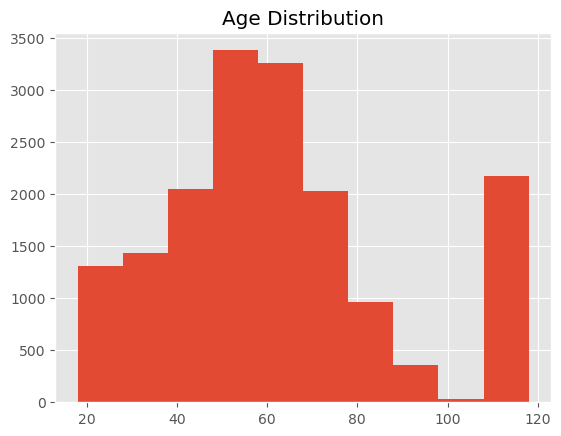

In [ ]:
# Check age distribution
#plt.figure(figsize=(17,4))
plt.hist(profile.age);
plt.title('Age Distribution');

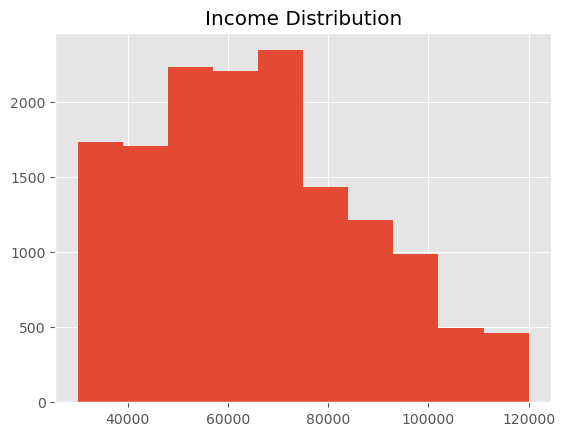

In [27]:
# Check `income` distribution
plt.hist(profile.income.dropna());
plt.title('Income Distribution');

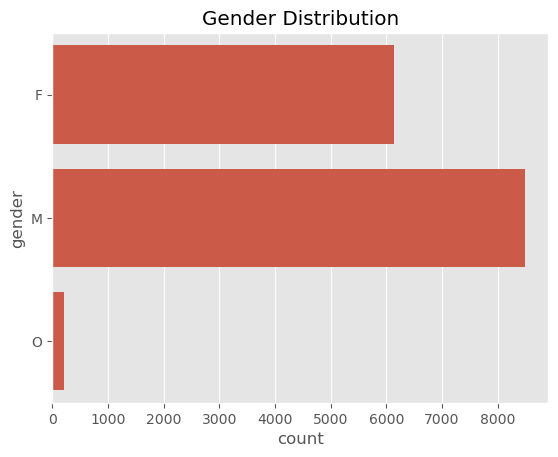

In [28]:
sns.countplot(profile.gender);
plt.title('Gender Distribution');

In [29]:
profile.gender.value_counts()

gender
M    8484
F    6129
O     212
Name: count, dtype: int64

**Conclusion:**

This dataset contains demographic data about members enrolled in the reward program with self-explanatory features. There are 17,000 rows (representing 17,000 customer profiles) and 5 columns. There are 2175 problematic rows with missing values and clear outliers. Aside from that, very little cleaning is required on this dataset.

### 2.2. `transcript` Dataset

**Schema:**
* `event` (str) - record description; transaction, offer received, offer viewed, or offer completed.
* `person` (str) - customer id.
* `time` (int) - time in hours since start of test. The data begins at time t=0.
* `value` - (dict) - either an offer id or transaction amount depending on the record.

In [30]:
transcript.tail()

,person,event,value,time
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714
306533,c02b10e8752c4d8e9b73f918558531f7,transaction,{'amount': 4.05},714


In [31]:
transcript.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   person  306534 non-null  object
 1   event   306534 non-null  object
 2   value   306534 non-null  object
 3   time    306534 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 9.4+ MB


In [32]:
transcript.event.value_counts()

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64

In [33]:
transcript.loc[transcript.event == 'transaction'].value.head()

12654    {'amount': 0.8300000000000001}
12657                 {'amount': 34.56}
12659                 {'amount': 13.23}
12670                 {'amount': 19.51}
12671                 {'amount': 18.97}
Name: value, dtype: object

In [34]:
transcript.loc[transcript.event == 'offer received'].value.head()

0    {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
1    {'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'}
2    {'offer id': '2906b810c7d4411798c6938adc9daaa5'}
3    {'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}
4    {'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}
Name: value, dtype: object

In [35]:
transcript.loc[transcript.event == 'offer viewed'].value.head()

12650    {'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}
12651    {'offer id': '5a8bc65990b245e5a138643cd4eb9837'}
12652    {'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}
12653    {'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'}
12655    {'offer id': '5a8bc65990b245e5a138643cd4eb9837'}
Name: value, dtype: object

In [36]:
transcript.loc[transcript.event == 'offer completed'].value.head()

12658    {'offer_id': '2906b810c7d4411798c6938adc9daaa5...
12672    {'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...
12679    {'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...
12692    {'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...
12697    {'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...
Name: value, dtype: object

In [37]:
transcript.loc[transcript.person == '78afa995795e4d85b5d9ceeca43f5fef']

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
15561,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},6
47582,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.89},132
47583,78afa995795e4d85b5d9ceeca43f5fef,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,132
49502,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 17.78},144
53176,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},168
85291,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},216
87134,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.67},222
92104,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 29.72},240
141566,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 23.93},378


In [38]:
# Check test period
print(transcript.time.max(), 'hours')
print(transcript.time.max() / 24, 'days')

714 hours
29.75 days


**Conclusion:**

This dataset contains records of activities related to the test simulated. Each record is time-stamped since the start of the test. The test start at t=0 and ends at t=714 (≈ 30 days). The nature of each record is described using `event`. The `value` column holds a value based on the `event` column. For offer received, viewed, and completed, the offer id is recorded. For transaction, the amount is recorded. Although this dataset is somehow abstract, 306534 rows and 4 columns, most of the cleaning process will be performed on this dataset.

<a id='data_preparation'></a>
## 3. Data Preparation

In this section, different compantions of techniques will be performed to produce the final dataset ready for modeling next section. Starting with cleaning the provided datasets, and then merging and aggregating data to form the final dataset. The final dataset will be grouped by customers profiles. The diagram below provide a high-level overview of the workflow followed in this project to produce final dataframe `coe` which stands for **C**ustomer-**O**ffer **E**ngagement.

<img src="images/workflow.png" style="margin: 10px 0px"/>
<center>Figure 1: Overview of Dataframes Manipulation</center>

# Data Cleaning

#### 3.1.1. `portfolio` Dataset

Starting be renaming columns `id` and `reward` to `offer_id` and `offered_reward` respectively. This serves readability. The latter in particular to make it distinguishable from a later added column `redeemed_reward`.

In [40]:
# Rename specified columns
portfolio.rename(columns={
    'id': 'offer_id',
    'reward': 'offered_reward'}, inplace=True)

One-hot encoding for columns `channels` and `offer_type` using utility function `one_hot_encoder`.

SyntaxError: invalid syntax (2466680001.py, line 1)